In [20]:
import os
import sys
sys.path.append('../src')
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
from tqdm import tqdm
from utils import set_seed

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


Подготовка данных и аугментация

In [21]:
DATA_DIR = '../data/raw'
IMG_SIZE = 224
BATCH_SIZE = 16

# Аугментации для обучения
train_transforms = T.Compose([
    T.RandomResizedCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Только нормализация для валидации
val_transforms = T.Compose([
    T.Resize(IMG_SIZE),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(DATA_DIR, transform=train_transforms)
classes = full_dataset.classes
num_classes = len(classes)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {classes}")
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

Classes: ['mugs', 'plates', 'tableware']
Train size: 75, Val size: 19


Функции обучения и визуализации

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds

def plot_confusion_matrix(labels, preds, classes):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

Эксперимент 1: ResNet

Evaluating: 100%|██████████| 2/2 [00:02<00:00,  1.42s/it]


Epoch 1/5 | Train Loss: 1.1354 Acc: 33.33% | Val Loss: 1.0198 Acc: 63.16%


Evaluating: 100%|██████████| 2/2 [00:03<00:00,  1.98s/it]


Epoch 2/5 | Train Loss: 1.0404 Acc: 58.67% | Val Loss: 1.0090 Acc: 73.68%


Evaluating: 100%|██████████| 2/2 [00:03<00:00,  1.78s/it]


...

Evaluating: 100%|██████████| 2/2 [00:03<00:00,  1.57s/it]


Epoch 4/5 | Train Loss: 0.8880 Acc: 92.00% | Val Loss: 0.9357 Acc: 73.68%


Evaluating: 100%|██████████| 2/2 [00:03<00:00,  1.54s/it]


Epoch 5/5 | Train Loss: 0.8402 Acc: 96.00% | Val Loss: 0.8627 Acc: 94.74%


Evaluating: 100%|██████████| 2/2 [00:02<00:00,  1.43s/it]


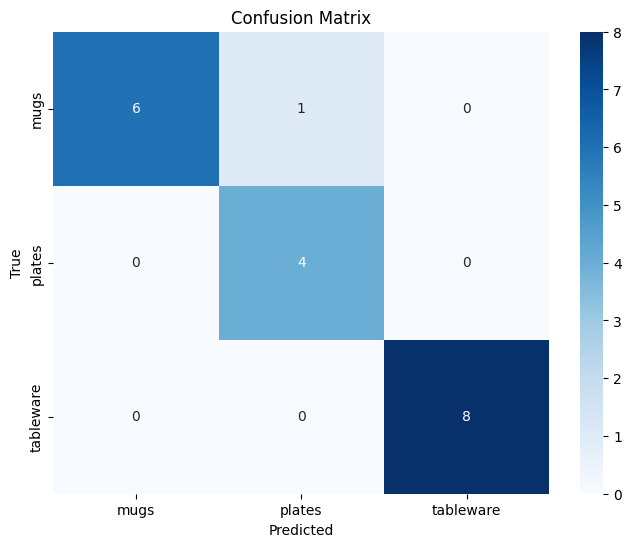

ResNet Final Val Accuracy: 94.74%


In [23]:
# 1. Создаем модель
model_name = 'resnet18'
model_resnet = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# 2. Стратегия заморозки: Замораживаем все слои, кроме последнего (Classifier)
for name, param in model_resnet.named_parameters():
    if "fc" not in name: # В resnet18 последний слой называется fc
        param.requires_grad = False
        
model_resnet = model_resnet.to(device)

criterion = nn.CrossEntropyLoss()
# Обучаем только последние слои, поэтому LR можно побольше
optimizer_resnet = torch.optim.Adam(filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=1e-3) 

# Цикл обучения (например, 5 эпох)
history_resnet = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epochs = 5

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_resnet, train_loader, criterion, optimizer_resnet, device)
    val_loss, val_acc, _, _ = evaluate(model_resnet, val_loader, criterion, device)
    
    history_resnet['train_loss'].append(train_loss)
    history_resnet['train_acc'].append(train_acc)
    history_resnet['val_loss'].append(val_loss)
    history_resnet['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

# Оценка и матрица ошибок
_, _, y_true, y_pred = evaluate(model_resnet, val_loader, criterion, device)
plot_confusion_matrix(y_true, y_pred, classes)
print(f"ResNet Final Val Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")

Эксперимент 2: EfficientNet

Evaluating: 100%|██████████| 2/2 [00:02<00:00,  1.48s/it]


Epoch 1/5 | Train Loss: 2.4960 Acc: 54.67% | Val Loss: 3.7258 Acc: 63.16%


Evaluating: 100%|██████████| 2/2 [00:02<00:00,  1.47s/it]


Epoch 2/5 | Train Loss: 0.0256 Acc: 98.67% | Val Loss: 1.6661 Acc: 68.42%


Evaluating: 100%|██████████| 2/2 [00:04<00:00,  2.28s/it]


...

Evaluating: 100%|██████████| 2/2 [00:04<00:00,  2.29s/it]


Epoch 4/5 | Train Loss: 0.0035 Acc: 100.00% | Val Loss: 0.3250 Acc: 94.74%


Evaluating: 100%|██████████| 2/2 [00:04<00:00,  2.15s/it]


Epoch 5/5 | Train Loss: 0.0003 Acc: 100.00% | Val Loss: 0.0262 Acc: 100.00%


Evaluating: 100%|██████████| 2/2 [00:04<00:00,  2.19s/it]


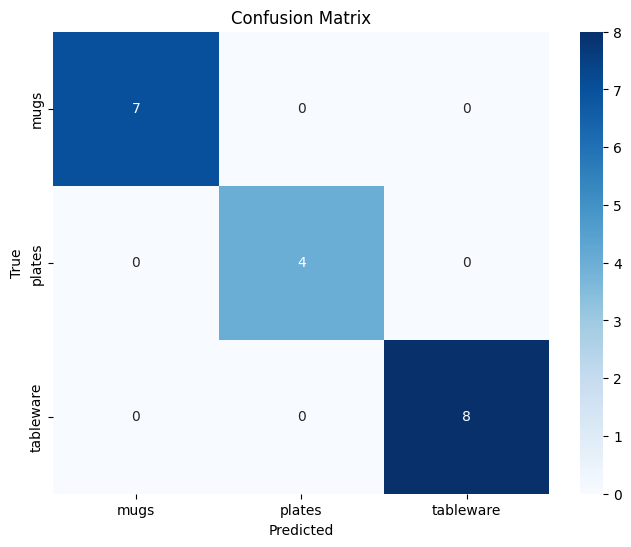

EfficientNet Final Val Accuracy: 100.00%


In [24]:
# 1. Создаем модель
model_name = 'efficientnet_b0'
model_eff = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# 2. Стратегия заморозки: Разморозим все, но используем очень маленький LR (Fine-tuning)
# Это альтернативная стратегия по сравнению с ResNet
for param in model_eff.parameters():
    param.requires_grad = True
        
model_eff = model_eff.to(device)

criterion = nn.CrossEntropyLoss()
# Маленький LR для всего слоя
optimizer_eff = torch.optim.AdamW(model_eff.parameters(), lr=1e-4, weight_decay=1e-4) 

history_eff = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_eff, train_loader, criterion, optimizer_eff, device)
    val_loss, val_acc, _, _ = evaluate(model_eff, val_loader, criterion, device)
    
    history_eff['train_loss'].append(train_loss)
    history_eff['train_acc'].append(train_acc)
    history_eff['val_loss'].append(val_loss)
    history_eff['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

# Оценка
_, _, y_true_eff, y_pred_eff = evaluate(model_eff, val_loader, criterion, device)
plot_confusion_matrix(y_true_eff, y_pred_eff, classes)
print(f"EfficientNet Final Val Accuracy: {accuracy_score(y_true_eff, y_pred_eff)*100:.2f}%")

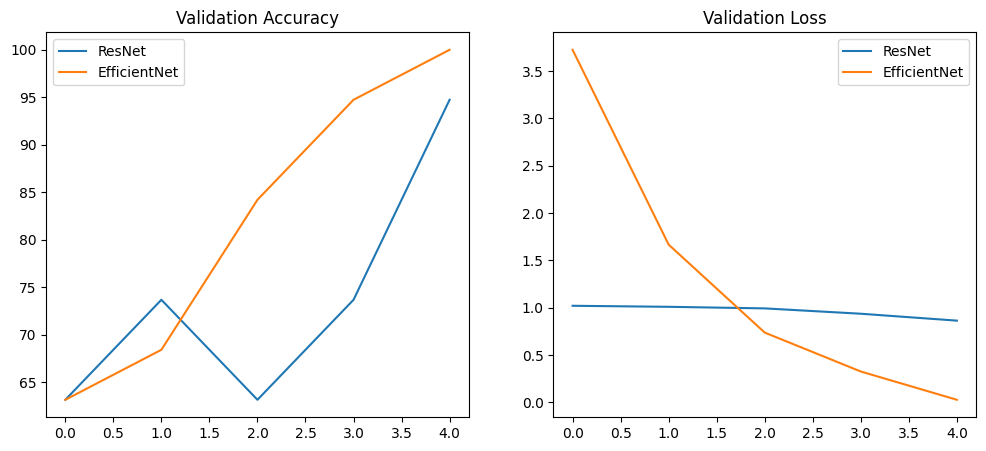

In [25]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_resnet['val_acc'], label='ResNet')
plt.plot(history_eff['val_acc'], label='EfficientNet')
plt.title('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet['val_loss'], label='ResNet')
plt.plot(history_eff['val_loss'], label='EfficientNet')
plt.title('Validation Loss')
plt.legend()
plt.show()